# 06 — Spatial Lag Modeling (Kalimantan Development)

This notebook tests whether **neighboring fire activity from the previous day** provides additional predictive information beyond the 20-feature Fire History + Weather benchmark.

**Development scope:** Kalimantan only.

## Research question

Does spatial neighborhood information improve next-day fire-active prediction?

## Spatial definition

The fire grid is regular at 0.75° spacing.

For each cell, Queen-style adjacency is used:

- horizontal neighbor
- vertical neighbor
- diagonal neighbor

Thus an interior cell can have up to 8 neighbors.

## Spatial features

1. `neighbor_fire_count_lag1`
   - mean fire count at neighboring cells on day t-1
2. `neighbor_fire_active_ratio_lag1`
   - proportion of neighboring cells with fire count > 0 on day t-1
3. `neighbor_frp_mean_lag1`
   - mean FRP sum at neighboring cells on day t-1

These are calculated from the already lagged fire-history variables in Notebook 04, so they do not use day t or t+1 information.

## Experiments

- LR + 20 benchmark features
- LR + 20 + spatial ratio
- LR + 20 + all 3 spatial features
- XGBoost + 20 benchmark features
- XGBoost + 20 + spatial ratio
- XGBoost + 20 + all 3 spatial features

The spatial experiment is an **ablation/extension**, not a replacement for the main benchmark.


In [28]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "karhut_ml_dataset_kalimantan.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Run Notebook 04 first."
    )

ml_data = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

ml_data = (
    ml_data
    .sort_values(["cell_id", "date"])
    .reset_index(drop=True)
)

print("Dataset shape:", ml_data.shape)
print("Date range:", ml_data["date"].min().date(), "→", ml_data["date"].max().date())
print("Unique cells:", ml_data["cell_id"].nunique())


Dataset shape: (34272, 29)
Date range: 2026-05-08 → 2026-09-10
Unique cells: 272


## 1. Define benchmark and target columns


In [29]:
fire_features = [
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7"
]

weather_features = [
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean"
]

features_20 = fire_features + weather_features
target = "target_fire_active_t1"

assert len(features_20) == 20

required = set(features_20 + [target, "grid_lat", "grid_lon", "cell_id", "date"])

missing = required - set(ml_data.columns)

if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")


## 2. Inspect spatial grid

The current fire cells use `grid_lat` and `grid_lon`. We do not parse coordinates from `cell_id`, because the identifier includes the region name.


In [30]:
cells = (
    ml_data[
        ["cell_id", "grid_lat", "grid_lon"]
    ]
    .drop_duplicates()
    .sort_values(["grid_lat", "grid_lon"])
    .reset_index(drop=True)
)

print("Number of cells:", len(cells))
print("Unique latitudes:", cells["grid_lat"].nunique())
print("Unique longitudes:", cells["grid_lon"].nunique())

lat_values = np.sort(cells["grid_lat"].unique())
lon_values = np.sort(cells["grid_lon"].unique())

print("\nLatitude spacing:")
print(np.unique(np.round(np.diff(lat_values), 8)))

print("\nLongitude spacing:")
print(np.unique(np.round(np.diff(lon_values), 8)))

if len(lat_values) > 1:
    lat_spacing = float(np.median(np.diff(lat_values)))
else:
    raise ValueError("Not enough latitude values to define adjacency.")

if len(lon_values) > 1:
    lon_spacing = float(np.median(np.diff(lon_values)))
else:
    raise ValueError("Not enough longitude values to define adjacency.")

print("\nDerived latitude spacing :", lat_spacing)
print("Derived longitude spacing:", lon_spacing)


Number of cells: 272
Unique latitudes: 17
Unique longitudes: 16

Latitude spacing:
[0.75]

Longitude spacing:
[0.75]

Derived latitude spacing : 0.75
Derived longitude spacing: 0.75


## 3. Build Queen adjacency

A neighbor is a cell whose latitude and longitude differ by at most one grid step, excluding the cell itself.


In [31]:
cell_lookup = {
    (round(row.grid_lat, 8), round(row.grid_lon, 8)): row.cell_id
    for row in cells.itertuples(index=False)
}

neighbor_dict = {}

for row in cells.itertuples(index=False):

    neighbors = []

    for dlat_step in [-1, 0, 1]:
        for dlon_step in [-1, 0, 1]:

            if dlat_step == 0 and dlon_step == 0:
                continue

            candidate = (
                round(row.grid_lat + dlat_step * lat_spacing, 8),
                round(row.grid_lon + dlon_step * lon_spacing, 8)
            )

            if candidate in cell_lookup:
                neighbors.append(cell_lookup[candidate])

    neighbor_dict[row.cell_id] = neighbors

neighbor_counts = pd.Series(
    {
        cell_id: len(neighbors)
        for cell_id, neighbors in neighbor_dict.items()
    },
    name="neighbor_count"
)

print("Cells in neighbor dictionary:", len(neighbor_dict))
print("\nNeighbor count distribution:")
display(
    neighbor_counts
    .value_counts()
    .sort_index()
    .to_frame("cells")
)

print("\nNeighbor count summary:")
display(neighbor_counts.describe())

if neighbor_counts.min() == 0:
    raise ValueError("At least one cell has no neighbors.")


Cells in neighbor dictionary: 272

Neighbor count distribution:


,cells
neighbor_count,
3,4
5,58
8,210



Neighbor count summary:


count    272.000000
mean       7.286765
std        1.335897
min        3.000000
25%        8.000000
50%        8.000000
75%        8.000000
max        8.000000
Name: neighbor_count, dtype: float64

## 4. Verify adjacency visually


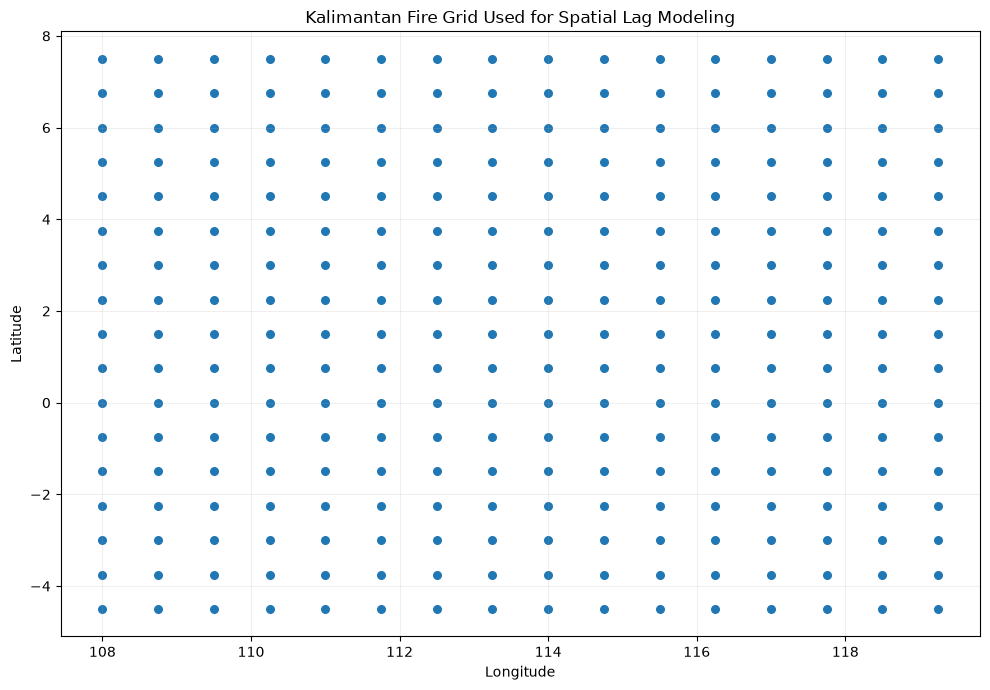

In [32]:
plt.figure(figsize=(10, 7))

plt.scatter(
    cells["grid_lon"],
    cells["grid_lat"],
    s=30
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Kalimantan Fire Grid Used for Spatial Lag Modeling")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 5. Compute spatial-lag features

Because `fire_count_lag1` and `frp_sum_lag1` already represent information from t-1, averaging them across neighboring cells produces spatial information from t-1.

No target value is used in these calculations.


In [33]:
# Build a compact lookup table keyed by date and cell.
fire_lag_lookup = ml_data[
    [
        "date",
        "cell_id",
        "fire_count_lag1",
        "frp_sum_lag1"
    ]
].copy()

# This should be unique because the ML dataset is one row per cell-day.
duplicate_lookup = fire_lag_lookup.duplicated(
    ["date", "cell_id"]
).sum()

print("Duplicate date-cell rows in lookup:", duplicate_lookup)

if duplicate_lookup:
    raise ValueError("Duplicate date-cell rows found.")


Duplicate date-cell rows in lookup: 0


In [34]:
# Pivot once for efficient spatial calculation.
count_pivot = (
    fire_lag_lookup
    .pivot(
        index="date",
        columns="cell_id",
        values="fire_count_lag1"
    )
)

frp_pivot = (
    fire_lag_lookup
    .pivot(
        index="date",
        columns="cell_id",
        values="frp_sum_lag1"
    )
)

print("Count pivot:", count_pivot.shape)
print("FRP pivot  :", frp_pivot.shape)


Count pivot: (126, 272)
FRP pivot  : (126, 272)


In [35]:
spatial_rows = []

for date in count_pivot.index:

    count_row = count_pivot.loc[date]
    frp_row = frp_pivot.loc[date]

    for cell_id in cells["cell_id"]:

        neighbors = neighbor_dict[cell_id]

        neighbor_counts_values = count_row.reindex(neighbors)
        neighbor_frp_values = frp_row.reindex(neighbors)

        spatial_rows.append({
            "date": date,
            "cell_id": cell_id,
            "neighbor_fire_count_lag1": neighbor_counts_values.mean(),
            "neighbor_fire_active_ratio_lag1": (
                (neighbor_counts_values > 0).mean()
            ),
            "neighbor_frp_mean_lag1": neighbor_frp_values.mean()
        })

spatial_features = pd.DataFrame(spatial_rows)

print("Spatial feature shape:", spatial_features.shape)
display(spatial_features.head())


Spatial feature shape: (34272, 5)


,date,cell_id,neighbor_fire_count_lag1,neighbor_fire_active_ratio_lag1,neighbor_frp_mean_lag1
0,2026-05-08,Kalimantan_-4.50_108.00,0.0,0.0,0.0
1,2026-05-08,Kalimantan_-4.50_108.75,0.0,0.0,0.0
2,2026-05-08,Kalimantan_-4.50_109.50,0.0,0.0,0.0
3,2026-05-08,Kalimantan_-4.50_110.25,0.0,0.0,0.0
4,2026-05-08,Kalimantan_-4.50_111.00,0.0,0.0,0.0


## 6. Merge spatial features into the ML dataset


In [36]:
spatial_data = ml_data.merge(
    spatial_features,
    on=["date", "cell_id"],
    how="left",
    validate="one_to_one"
)

spatial_cols = [
    "neighbor_fire_count_lag1",
    "neighbor_fire_active_ratio_lag1",
    "neighbor_frp_mean_lag1"
]

print("Merged shape:", spatial_data.shape)

print("\nMissing spatial features:")
display(
    spatial_data[spatial_cols]
    .isna()
    .sum()
    .to_frame("missing")
)

if spatial_data[spatial_cols].isna().any().any():
    raise ValueError("Missing spatial features detected.")


Merged shape: (34272, 32)

Missing spatial features:


,missing
neighbor_fire_count_lag1,0
neighbor_fire_active_ratio_lag1,0
neighbor_frp_mean_lag1,0


## 7. Spatial feature distributions


In [37]:
display(
    spatial_data[spatial_cols].describe().T
)


,count,mean,std,min,25%,50%,75%,max
neighbor_fire_count_lag1,34272.0,4.071525,17.574515,0.0,0.0,0.0,0.800000,385.62500
neighbor_fire_active_ratio_lag1,34272.0,0.181750,0.262485,0.0,0.0,0.0,0.250000,1.00000
neighbor_frp_mean_lag1,34272.0,32.666461,149.285258,0.0,0.0,0.0,3.961438,3724.92375


## 8. Spatial ratio versus next-day target

This is a descriptive diagnostic only. A strong association does not imply a causal effect.


In [38]:
ratio = spatial_data["neighbor_fire_active_ratio_lag1"]

ratio_bins = pd.cut(
    ratio,
    bins=[-0.001, 0, 0.25, 0.50, 0.75, 1.0],
    labels=[
        "0%",
        ">0–25%",
        ">25–50%",
        ">50–75%",
        ">75–100%"
    ]
)

ratio_summary = (
    spatial_data
    .groupby(ratio_bins, observed=False)[target]
    .agg(
        samples="count",
        target_rate="mean"
    )
)

ratio_summary["target_rate"] *= 100

display(ratio_summary)


,samples,target_rate
neighbor_fire_active_ratio_lag1,,
0%,17901,5.273448
>0–25%,8609,14.066674
>25–50%,3945,33.257288
>50–75%,2180,64.908257
>75–100%,1637,85.522297


## 9. Correlation with selected Fire History features

This diagnostic helps determine whether spatial features contain overlapping information with local fire persistence.


In [39]:
corr_features = [
    "fire_count_lag1",
    "fire_count_roll7",
    "frp_sum_lag1",
    "frp_sum_roll7"
]

pearson = (
    spatial_data[
        [spatial_cols[1]] + corr_features
    ]
    .corr(method="pearson")[spatial_cols[1]]
    .drop(spatial_cols[1])
    .sort_values(ascending=False)
)

spearman = (
    spatial_data[
        [spatial_cols[1]] + corr_features
    ]
    .corr(method="spearman")[spatial_cols[1]]
    .drop(spatial_cols[1])
    .sort_values(ascending=False)
)

print("Pearson correlation:")
display(pearson.to_frame("correlation"))

print("\nSpearman correlation:")
display(spearman.to_frame("correlation"))


Pearson correlation:


,correlation
frp_sum_roll7,0.373319
fire_count_roll7,0.372914
fire_count_lag1,0.355038
frp_sum_lag1,0.325631



Spearman correlation:


,correlation
fire_count_lag1,0.587532
frp_sum_lag1,0.587301
fire_count_roll7,0.572797
frp_sum_roll7,0.570174


## 10. Temporal split

The split is identical to Notebook 05.


In [40]:
train = spatial_data[
    spatial_data["date"] < "2026-08-01"
].copy()

val = spatial_data[
    (spatial_data["date"] >= "2026-08-01") &
    (spatial_data["date"] < "2026-09-01")
].copy()

test = spatial_data[
    spatial_data["date"] >= "2026-09-01"
].copy()

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(train), len(val), len(test)],
    "Positive Rate": [
        train[target].mean(),
        val[target].mean(),
        test[target].mean()
    ],
    "Start": [
        train["date"].min(),
        val["date"].min(),
        test["date"].min()
    ],
    "End": [
        train["date"].max(),
        val["date"].max(),
        test["date"].max()
    ]
})

display(split_summary)


,Split,Rows,Positive Rate,Start,End
0,Train,23120,0.110424,2026-05-08,2026-07-31
1,Validation,8432,0.339184,2026-08-01,2026-08-31
2,Test,2720,0.319485,2026-09-01,2026-09-10


## 11. Evaluation helper


In [41]:
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred)
    }

    cm = confusion_matrix(y_true, y_pred)

    return metrics, cm


## 12. Logistic Regression — baseline with 20 features


In [42]:
features_B0 = features_20

lr_B0 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_B0.fit(
    train[features_B0],
    train[target].astype(int)
)

lr_B0_val_prob = lr_B0.predict_proba(
    val[features_B0]
)[:, 1]

lr_B0_metrics, lr_B0_cm = evaluate_predictions(
    val[target].astype(int),
    lr_B0_val_prob,
    threshold=0.5
)

print("=== B0 — LR + 20 Benchmark Features ===")
for k, v in lr_B0_metrics.items():
    print(f"{k:10s}: {v:.6f}")


=== B0 — LR + 20 Benchmark Features ===
PR-AUC    : 0.901149
Precision : 0.677419
Recall    : 0.925175
F1        : 0.782146
Accuracy  : 0.825190


## 13. Logistic Regression + Spatial Ratio


In [43]:
features_B1 = features_20 + [
    "neighbor_fire_active_ratio_lag1"
]

lr_B1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_B1.fit(
    train[features_B1],
    train[target].astype(int)
)

lr_B1_val_prob = lr_B1.predict_proba(
    val[features_B1]
)[:, 1]

lr_B1_metrics, lr_B1_cm = evaluate_predictions(
    val[target].astype(int),
    lr_B1_val_prob,
    threshold=0.5
)

print("=== B1 — LR + Spatial Ratio ===")
for k, v in lr_B1_metrics.items():
    print(f"{k:10s}: {v:.6f}")


=== B1 — LR + Spatial Ratio ===
PR-AUC    : 0.897316
Precision : 0.637506
Recall    : 0.940210
F1        : 0.759819
Accuracy  : 0.798387


## 14. Logistic Regression + all three spatial features


In [44]:
features_B2 = features_20 + spatial_cols

lr_B2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_B2.fit(
    train[features_B2],
    train[target].astype(int)
)

lr_B2_val_prob = lr_B2.predict_proba(
    val[features_B2]
)[:, 1]

lr_B2_metrics, lr_B2_cm = evaluate_predictions(
    val[target].astype(int),
    lr_B2_val_prob,
    threshold=0.5
)

print("=== B2 — LR + Three Spatial Features ===")
for k, v in lr_B2_metrics.items():
    print(f"{k:10s}: {v:.6f}")


=== B2 — LR + Three Spatial Features ===
PR-AUC    : 0.887315
Precision : 0.626248
Recall    : 0.920979
F1        : 0.745542
Accuracy  : 0.786765


## 15. XGBoost + 20 benchmark features


In [45]:
xgb_train_y = train[target].astype(int)

neg = (xgb_train_y == 0).sum()
pos = (xgb_train_y == 1).sum()
scale_pos_weight = neg / pos

xgb_B0 = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_B0.fit(
    train[features_20],
    xgb_train_y
)

xgb_B0_val_prob = xgb_B0.predict_proba(
    val[features_20]
)[:, 1]

xgb_B0_metrics, xgb_B0_cm = evaluate_predictions(
    val[target].astype(int),
    xgb_B0_val_prob,
    threshold=0.5
)

print("=== XGB B0 — 20 Benchmark Features ===")
for k, v in xgb_B0_metrics.items():
    print(f"{k:10s}: {v:.6f}")


=== XGB B0 — 20 Benchmark Features ===
PR-AUC    : 0.890953
Precision : 0.683947
Recall    : 0.954895
F1        : 0.797023
Accuracy  : 0.835033


## 16. XGBoost + spatial ratio


In [46]:
features_D1 = features_20 + [
    "neighbor_fire_active_ratio_lag1"
]

xgb_D1 = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_D1.fit(
    train[features_D1],
    xgb_train_y
)

xgb_D1_val_prob = xgb_D1.predict_proba(
    val[features_D1]
)[:, 1]

xgb_D1_metrics, xgb_D1_cm = evaluate_predictions(
    val[target].astype(int),
    xgb_D1_val_prob,
    threshold=0.5
)

print("=== XGB D1 — 20 + Spatial Ratio ===")
for k, v in xgb_D1_metrics.items():
    print(f"{k:10s}: {v:.6f}")


=== XGB D1 — 20 + Spatial Ratio ===
PR-AUC    : 0.876502
Precision : 0.664733
Recall    : 0.961538
F1        : 0.786051
Accuracy  : 0.822462


## 17. XGBoost + all three spatial features


In [47]:
features_D2 = features_20 + spatial_cols

xgb_D2 = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_D2.fit(
    train[features_D2],
    xgb_train_y
)

xgb_D2_val_prob = xgb_D2.predict_proba(
    val[features_D2]
)[:, 1]

xgb_D2_metrics, xgb_D2_cm = evaluate_predictions(
    val[target].astype(int),
    xgb_D2_val_prob,
    threshold=0.5
)

print("=== XGB D2 — 20 + Three Spatial Features ===")
for k, v in xgb_D2_metrics.items():
    print(f"{k:10s}: {v:.6f}")


=== XGB D2 — 20 + Three Spatial Features ===
PR-AUC    : 0.873299
Precision : 0.658764
Recall    : 0.961888
F1        : 0.781978
Accuracy  : 0.818074


## 18. Validation comparison

All experiments use the same August validation period.


In [48]:
spatial_validation_results = pd.DataFrame([
    {
        "Model": "LR + 20 Benchmark",
        **lr_B0_metrics
    },
    {
        "Model": "LR + Spatial Ratio",
        **lr_B1_metrics
    },
    {
        "Model": "LR + 3 Spatial Features",
        **lr_B2_metrics
    },
    {
        "Model": "XGBoost + 20 Benchmark",
        **xgb_B0_metrics
    },
    {
        "Model": "XGBoost + Spatial Ratio",
        **xgb_D1_metrics
    },
    {
        "Model": "XGBoost + 3 Spatial Features",
        **xgb_D2_metrics
    }
])

display(spatial_validation_results)


,Model,PR-AUC,Precision,Recall,F1,Accuracy
0,LR + 20 Benchmark,0.901149,0.677419,0.925175,0.782146,0.825190
1,LR + Spatial Ratio,0.897316,0.637506,0.940210,0.759819,0.798387
2,LR + 3 Spatial Features,0.887315,0.626248,0.920979,0.745542,0.786765
3,XGBoost + 20 Benchmark,0.890953,0.683947,0.954895,0.797023,0.835033
4,XGBoost + Spatial Ratio,0.876502,0.664733,0.961538,0.786051,0.822462
5,XGBoost + 3 Spatial Features,0.873299,0.658764,0.961888,0.781978,0.818074


## 19. Spatial feature importance — XGBoost

This is a model-specific importance diagnostic, not a causal interpretation.


In [49]:
importance_D2 = pd.Series(
    xgb_D2.feature_importances_,
    index=features_D2
).sort_values(
    ascending=False
)

display(
    importance_D2.head(20).to_frame("Importance")
)


,Importance
frp_sum_roll7,0.321562
fire_count_roll7,0.228529
frp_sum_roll3,0.049665
neighbor_fire_active_ratio_lag1,0.045046
frp_sum_lag1,0.033941
neighbor_frp_mean_lag1,0.032675
frp_sum_lag7,0.031209
precipitation_sum,0.030140
boundary_layer_height_mean,0.025333
neighbor_fire_count_lag1,0.023121


## 20. Test evaluation

The spatial experiments are evaluated on September after the validation comparison.

Threshold = 0.50 is kept fixed to match the validation operating point and avoid tuning on the test set.


In [50]:
test_results = []

test_models = [
    ("LR + 20 Benchmark", lr_B0, features_20),
    ("LR + Spatial Ratio", lr_B1, features_B1),
    ("LR + 3 Spatial Features", lr_B2, features_B2),
    ("XGBoost + 20 Benchmark", xgb_B0, features_20),
    ("XGBoost + Spatial Ratio", xgb_D1, features_D1),
    ("XGBoost + 3 Spatial Features", xgb_D2, features_D2)
]

for name, model, feature_list in test_models:

    prob = model.predict_proba(
        test[feature_list]
    )[:, 1]

    metrics, cm = evaluate_predictions(
        test[target].astype(int),
        prob,
        threshold=0.5
    )

    test_results.append({
        "Model": name,
        **metrics
    })

    print(f"\n=== {name} — Test ===")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.6f}")
    print("Confusion Matrix:")
    print(cm)

spatial_test_results = pd.DataFrame(test_results)

display(spatial_test_results)



=== LR + 20 Benchmark — Test ===
PR-AUC    : 0.896144
Precision : 0.617825
Recall    : 0.941312
F1        : 0.746010
Accuracy  : 0.795221
Confusion Matrix:
[[1345  506]
 [  51  818]]

=== LR + Spatial Ratio — Test ===
PR-AUC    : 0.897698
Precision : 0.581072
Recall    : 0.960875
F1        : 0.724198
Accuracy  : 0.766176
Confusion Matrix:
[[1249  602]
 [  34  835]]

=== LR + 3 Spatial Features — Test ===
PR-AUC    : 0.889843
Precision : 0.571331
Recall    : 0.963176
F1        : 0.717224
Accuracy  : 0.757353
Confusion Matrix:
[[1223  628]
 [  32  837]]

=== XGBoost + 20 Benchmark — Test ===
PR-AUC    : 0.901825
Precision : 0.620132
Recall    : 0.971231
F1        : 0.756951
Accuracy  : 0.800735
Confusion Matrix:
[[1334  517]
 [  25  844]]

=== XGBoost + Spatial Ratio — Test ===
PR-AUC    : 0.892469
Precision : 0.594803
Recall    : 0.974684
F1        : 0.738770
Accuracy  : 0.779779
Confusion Matrix:
[[1274  577]
 [  22  847]]

=== XGBoost + 3 Spatial Features — Test ===
PR-AUC    : 0.889

,Model,PR-AUC,Precision,Recall,F1,Accuracy
0,LR + 20 Benchmark,0.896144,0.617825,0.941312,0.746010,0.795221
1,LR + Spatial Ratio,0.897698,0.581072,0.960875,0.724198,0.766176
2,LR + 3 Spatial Features,0.889843,0.571331,0.963176,0.717224,0.757353
3,XGBoost + 20 Benchmark,0.901825,0.620132,0.971231,0.756951,0.800735
4,XGBoost + Spatial Ratio,0.892469,0.594803,0.974684,0.738770,0.779779
5,XGBoost + 3 Spatial Features,0.889577,0.593706,0.976985,0.738582,0.779044


## 21. Spatial ratio confusion matrix


In [51]:
_, lr_b1_test_cm = evaluate_predictions(
    test[target].astype(int),
    lr_B1.predict_proba(test[features_B1])[:, 1],
    threshold=0.5
)

print("LR + Spatial Ratio — Test Confusion Matrix")
print(lr_b1_test_cm)


LR + Spatial Ratio — Test Confusion Matrix
[[1249  602]
 [  34  835]]


## 22. Save spatial experiment outputs


In [52]:
RESULTS_DIR = PROJECT_ROOT / "data" / "processed" / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

spatial_features_output = RESULTS_DIR / "spatial_features_kalimantan.csv"
spatial_validation_output = RESULTS_DIR / "spatial_validation_results.csv"
spatial_test_output = RESULTS_DIR / "spatial_test_results.csv"
spatial_importance_output = RESULTS_DIR / "xgb_spatial_feature_importance.csv"

spatial_features.to_csv(
    spatial_features_output,
    index=False
)

spatial_validation_results.to_csv(
    spatial_validation_output,
    index=False
)

spatial_test_results.to_csv(
    spatial_test_output,
    index=False
)

importance_D2.rename(
    "Importance"
).to_csv(
    spatial_importance_output
)

print("Saved:")
print(spatial_features_output)
print(spatial_validation_output)
print(spatial_test_output)
print(spatial_importance_output)


Saved:
c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\spatial_features_kalimantan.csv
c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\spatial_validation_results.csv
c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\spatial_test_results.csv
c:\Users\Asus\Documents\skripsi-karhut\data\processed\model_results\xgb_spatial_feature_importance.csv


# Notebook 06 — Conclusion

This notebook evaluates whether previous-day neighborhood fire activity adds predictive value beyond the 20-feature Fire History + Weather benchmark.

The experiment should be interpreted as a **controlled spatial extension**:

```text
20 benchmark features
        ↓
+ spatial neighborhood information
        ↓
compare validation PR-AUC
        ↓
evaluate selected spatial variants on test
```

The spatial features are derived only from t-1 information, so they are compatible with the t → t+1 forecasting setup.

Do not interpret correlation or feature importance as causality.

The final thesis conclusion should be based on the complete benchmark, ablation, and spatial experiments rather than on one metric alone.
